1) step 1: For each point initially we will consider as a separate cluster.  
2) step 2: Find the nearest point and create a new cluster  
3) step 3: Keep on doing the process [step2] until we get a single cluster

Types:  
1)Agglomerative(bottom-up)  
2)Divisive(Top-down)  

Linkage Types:
1) Single Linkage : min distance
2) Complete Linkage : max distance
3) Average Distance : mean distance

How many clusters??
1) Dendogram :  
  To find threshold:the longest line on which no horizantal line passes through

Cosine Similarity:





low dimension-->euclidean  
high dimension-->manhattan

# Agglomerative Clustering


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [38]:
data=pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [39]:
data.columns=['CustomerID','Gender','Age','Annual Income','Spending Score']

In [40]:
data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [41]:
data.isna().sum()

CustomerID        0
Gender            0
Age               0
Annual Income     0
Spending Score    0
dtype: int64

In [42]:
data.drop(columns=['CustomerID','Gender'],inplace=True,axis=1)

In [43]:
data.head()

,Age,Annual Income,Spending Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


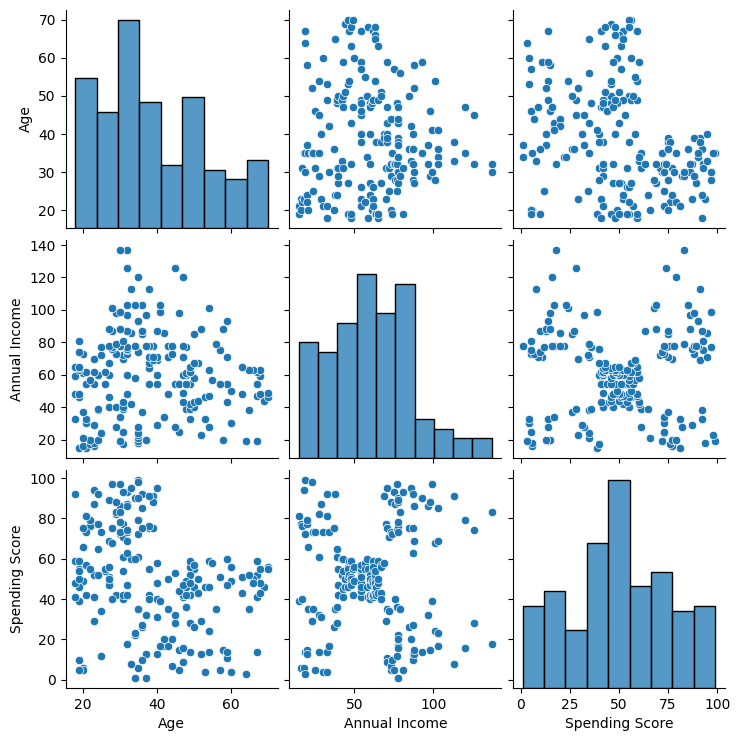

In [44]:
#EDA

sns.pairplot(data)
plt.show()

In [47]:
#correlation
'''
plt.title('Correlation matrix')
plt.show() 

'''

"\nplt.title('Correlation matrix')\nplt.show() \n\n"

In [56]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
data=scaler.fit_transform(data)

In [57]:
data

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [58]:
#train model

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage



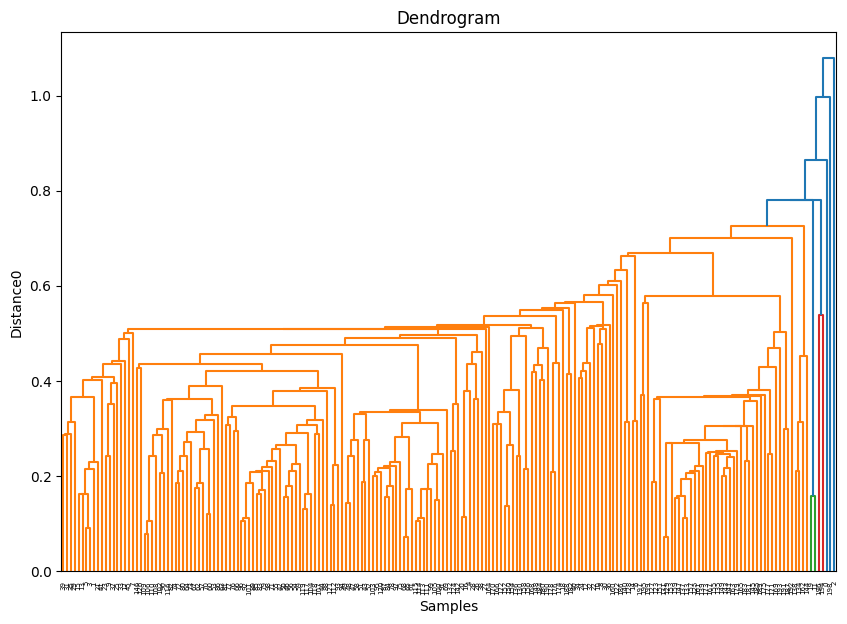

In [59]:
linked=linkage(data,method='single')
plt.figure(figsize=(10,7))
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance0')
plt.show()

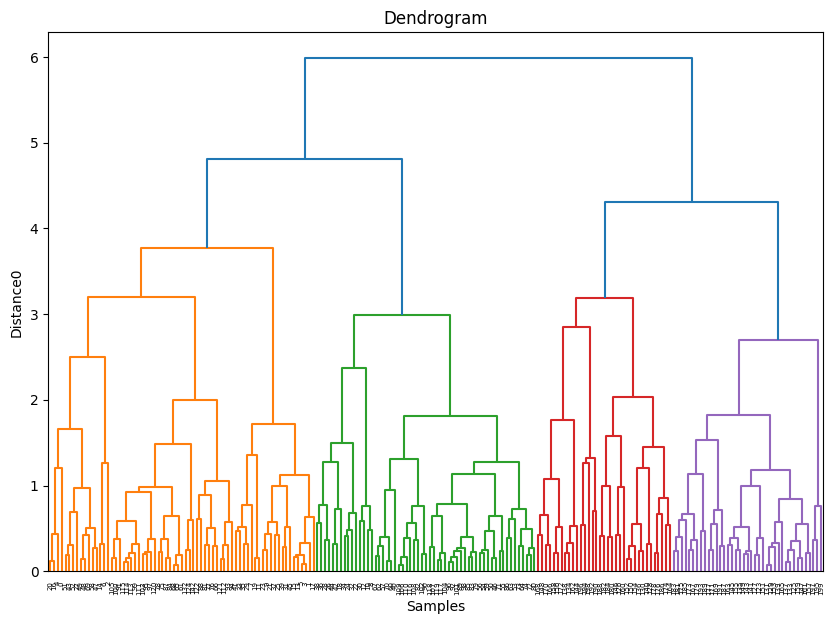

In [60]:
linked=linkage(data,method='complete')
plt.figure(figsize=(10,7))
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance0')
plt.show()

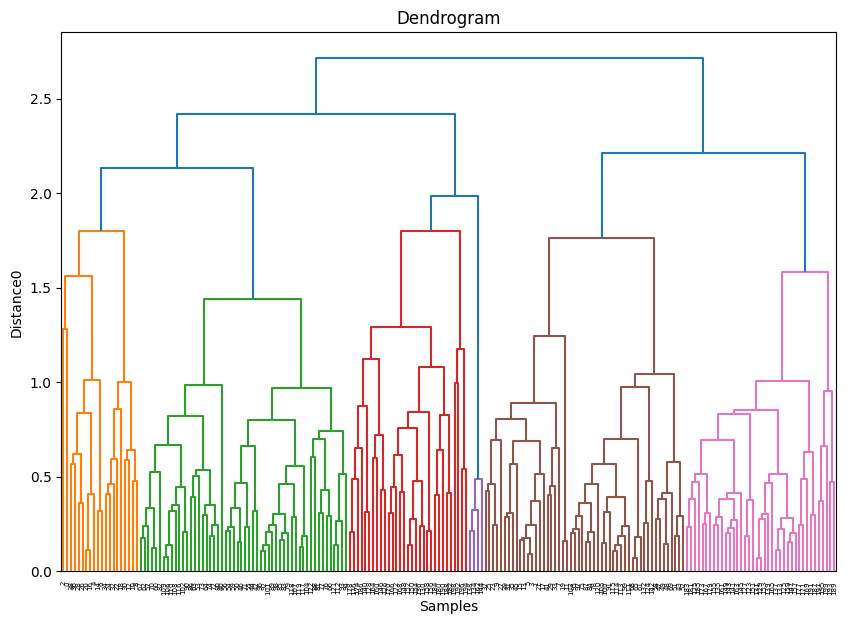

In [61]:
linked=linkage(data,method='average')
plt.figure(figsize=(10,7))
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance0')
plt.show()

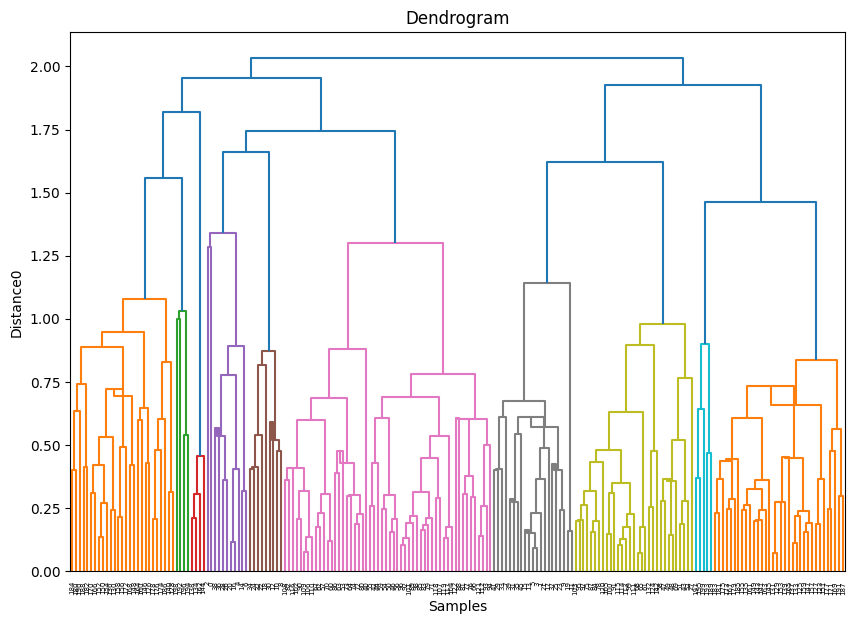

In [62]:
linked=linkage(data,method='centroid')
plt.figure(figsize=(10,7))
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance0')
plt.show()

In [65]:
data=pd.DataFrame(data,columns=['Age','Annual-Income','Spending Score'])
data.head()

,Age,Annual-Income,Spending Score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [67]:
# train the model algomerastive clustering 
from sklearn.cluster import AgglomerativeClustering


model=AgglomerativeClustering(n_clusters=5,linkage='ward')
agglomerative_clusters=model.fit_predict(data)
model.fit(data)
data['labels']=model.labels_

In [68]:
data.head()

,Age,Annual-Income,Spending Score,labels
0,-1.424569,-1.738999,-0.434801,4
1,-1.281035,-1.738999,1.195704,0
2,-1.352802,-1.700830,-1.715913,4
3,-1.137502,-1.700830,1.040418,0
4,-0.563369,-1.662660,-0.395980,4


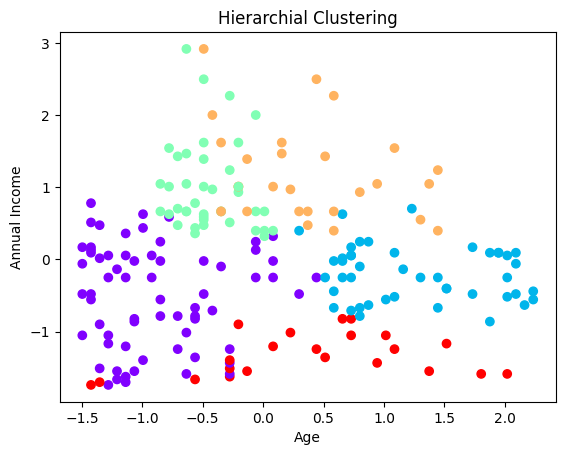

In [28]:
#visualization

plt.scatter(data[:,0],data[:,1],c=labels,cmap='rainbow')
plt.title('Hierarchial Clustering')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.show()

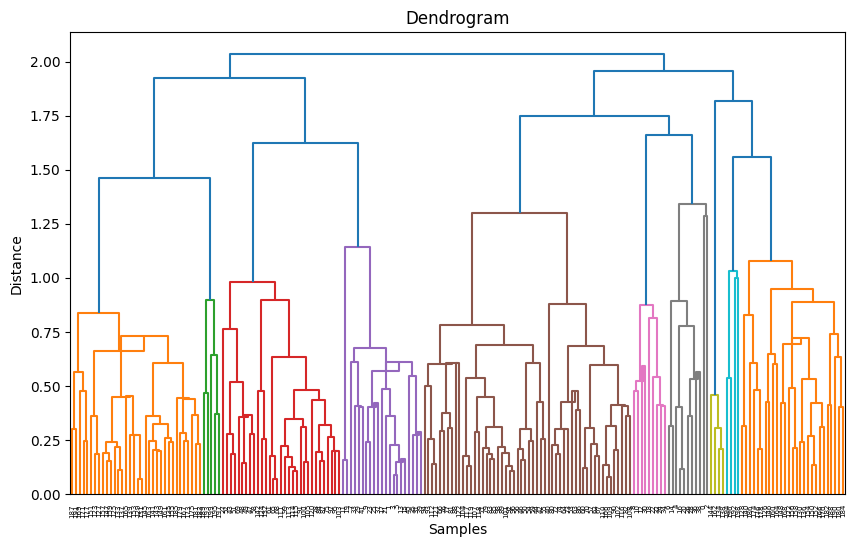

In [33]:
#plot dendrogram with threshold

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.axhline(y=150,color='r',linestyle='--')
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [34]:
# find the number of clusters using Threshold 
from scipy.cluster.hierarchy import fcluster

clusters=fcluster(linked,t=150,criterion='distance')
n_clusters=len(set(clusters))
print(f'No of clusters {n_clusters}')

No of clusters 1


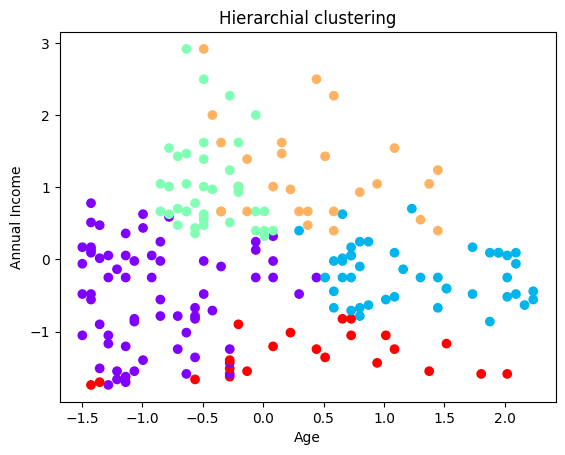

In [32]:
plt.scatter(data[:,0],data[:,1],c=labels,cmap='rainbow')
plt.title("Hierarchial clustering")
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.show()

In [71]:
import joblib
joblib.dump(model,'hierarchial_model.pkl')

['hierarchial_model.pkl']

In [72]:
# saved dataset
data.to_csv('Mall_clustered.csv',index=False)

In [73]:
##Try supervised model
X=data.drop(columns=['labels'])
y = data['labels']

# Splitting parts

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)